In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/daily-demand-series.csv')

df['date'] = pd.to_datetime(df['date'])

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe())

Shape: (30, 4)

Columns:
['date', 'demand', 'marketing_event', 'holiday']

Data types:
date               datetime64[ns]
demand                      int64
marketing_event             int64
holiday                     int64
dtype: object

Missing values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

Summary:
                      date      demand  marketing_event    holiday
count                   30   30.000000        30.000000  30.000000
mean   2026-06-15 12:00:00  142.100000         0.266667   0.133333
min    2026-06-01 00:00:00  118.000000         0.000000   0.000000
25%    2026-06-08 06:00:00  132.500000         0.000000   0.000000
50%    2026-06-15 12:00:00  142.000000         0.000000   0.000000
75%    2026-06-22 18:00:00  150.250000         0.750000   0.000000
max    2026-06-30 00:00:00  174.000000         1.000000   1.000000
std                    NaN   13.839848         0.449776   0.345746


In [ ]:
df = df.sort_values('date')
df = df.set_index('date')

demand = df['demand']

print(demand)

date
2026-06-01    118
2026-06-02    121
2026-06-03    125
2026-06-04    123
2026-06-05    137
2026-06-06    151
2026-06-07    143
2026-06-08    126
2026-06-09    129
2026-06-10    132
2026-06-11    135
2026-06-12    148
2026-06-13    160
2026-06-14    146
2026-06-15    131
2026-06-16    134
2026-06-17    139
2026-06-18    141
2026-06-19    154
2026-06-20    168
2026-06-21    152
2026-06-22    137
2026-06-23    140
2026-06-24    144
2026-06-25    147
2026-06-26    161
2026-06-27    174
2026-06-28    158
2026-06-29    143
2026-06-30    146
Name: demand, dtype: int64


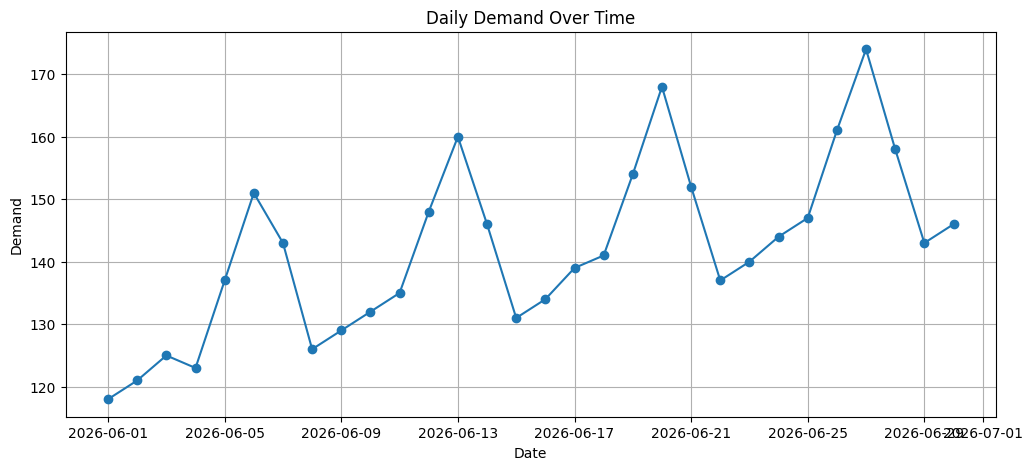

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(demand, marker='o')

plt.title('Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True)

plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

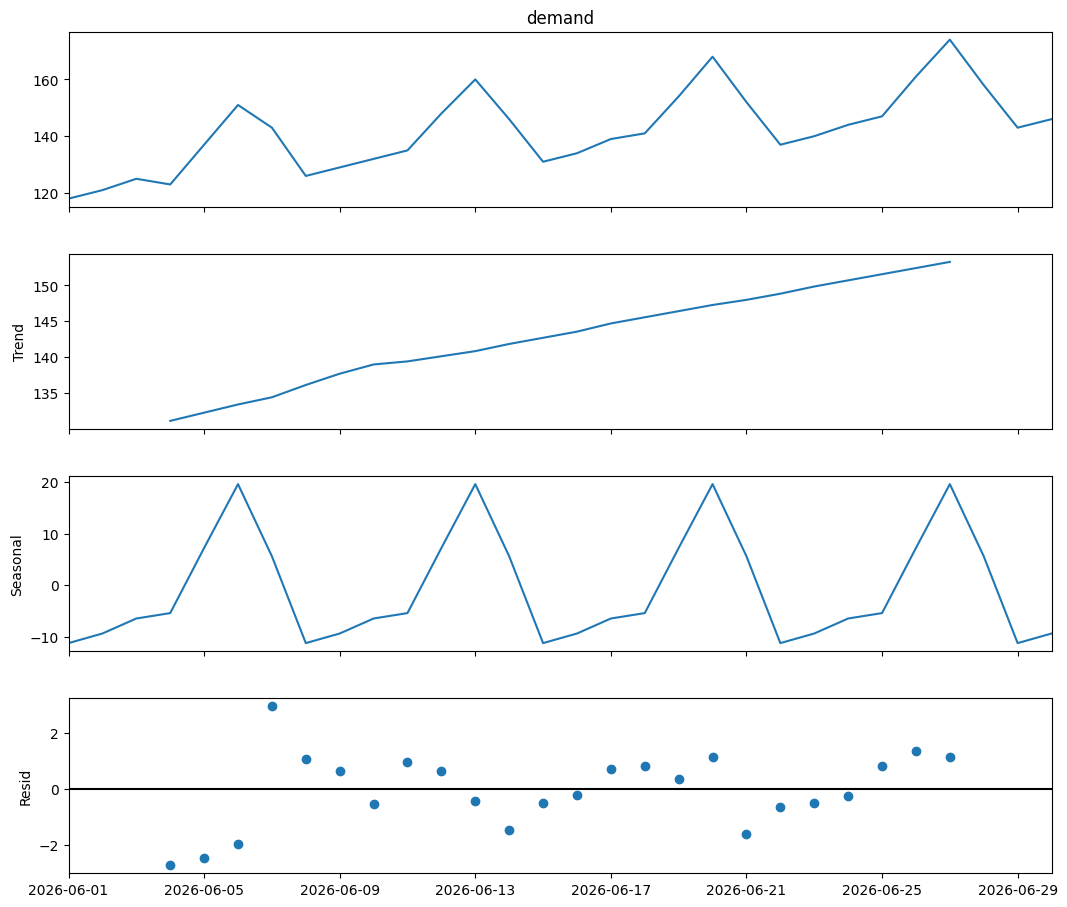

In [ ]:
decomposition = seasonal_decompose(
      demand,
          model='additive',
              period=7
              )

fig = decomposition.plot()

fig.set_size_inches(12, 10)

plt.show()


In [28]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(demand.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

    if result[1] <= 0.05:
        print("\nResult: The series is stationary.")
    else:
        print("\nResult: The series is not stationary.")

ADF Statistic: -0.9038698873856339
p-value: 0.7866953368372341

Critical Values:
1%: -3.769732625845229

Result: The series is not stationary.
5%: -3.005425537190083

Result: The series is not stationary.
10%: -2.6425009917355373

Result: The series is not stationary.


/tmp/ipykernel_895/555133796.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(demand.dropna())


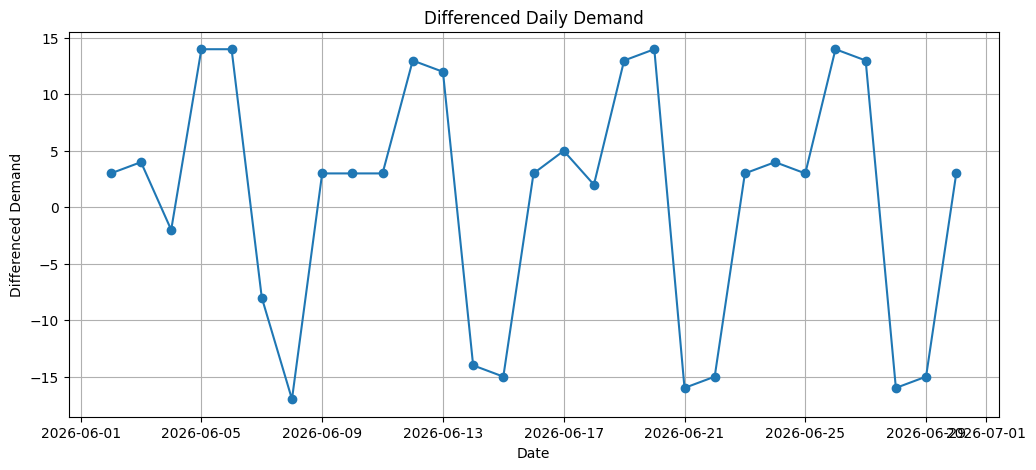

In [29]:
demand_diff = demand.diff().dropna()

plt.figure(figsize=(12, 5))

plt.plot(demand_diff, marker='o')

plt.title('Differenced Daily Demand')
plt.xlabel('Date')
plt.ylabel('Differenced Demand')
plt.grid(True)

plt.show()

In [30]:
result_diff = adfuller(demand_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

if result_diff[1] <= 0.05:
    print("\nResult: Differenced series is stationary.")
else:
    print("\nResult: Differenced series is still not stationary.")

ADF Statistic: -2.233624012735415
p-value: 0.19426893706635578

Result: Differenced series is still not stationary.


/tmp/ipykernel_895/3272113554.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(demand_diff)


In [31]:
train = demand.iloc[:-7]
test = demand.iloc[-7:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 23
Testing observations: 7

Training period:
2026-06-01 00:00:00 to 2026-06-23 00:00:00

Testing period:
2026-06-24 00:00:00 to 2026-06-30 00:00:00


In [33]:
from statsmodels.tsa.arima.model import ARIMA

In [34]:
model = ARIMA(train, order=(1, 1, 1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   23
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -79.120
Date:                Wed, 07 Oct 2026   AIC                            164.240
Time:                        08:33:43   BIC                            167.514
Sample:                    06-01-2026   HQIC                           165.011
                         - 06-23-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1515      0.395     -0.384      0.701      -0.925       0.622
ma.L1          0.8070      0.191      4.230      0.000       0.433       1.181
sigma2        75.0205     27.853      2.693      0.0

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [35]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

print(forecast)

date
2026-06-24    141.930901
2026-06-25    141.638279
2026-06-26    141.682625
2026-06-27    141.675905
2026-06-28    141.676923
2026-06-29    141.676769
2026-06-30    141.676792
Name: predicted_mean, dtype: float64


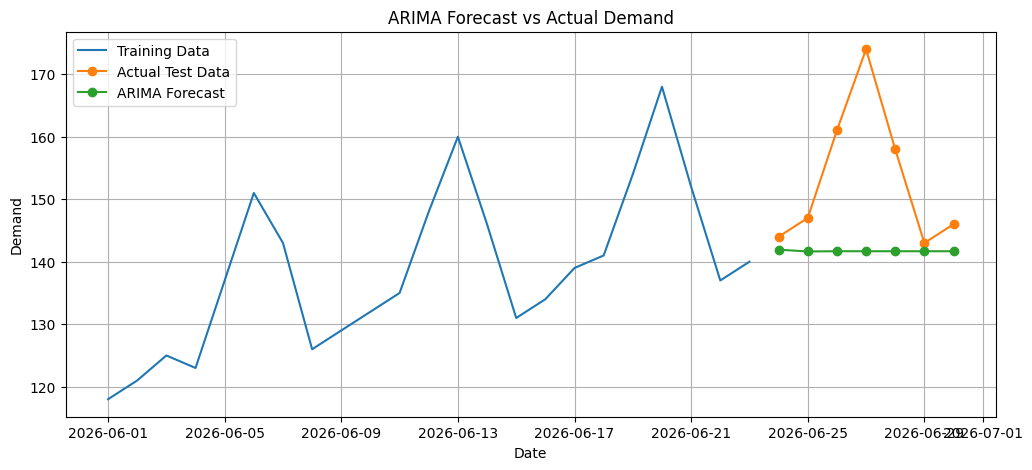

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Data', marker='o')
plt.plot(forecast.index, forecast, label='ARIMA Forecast', marker='o')

plt.title('ARIMA Forecast vs Actual Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()

In [37]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, forecast) * 100
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

MAPE: 7.13%
RMSE: 15.76


In [42]:
final_model = ARIMA(demand, order=(1, 1, 1))

final_model_fit = final_model.fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [43]:
future_forecast = final_model_fit.forecast(steps=30)

future_dates = pd.date_range(
    start=demand.index[-1] + pd.Timedelta(days=1),
        periods=30,
            freq='D'
            )
future_forecast.index = future_dates

print(future_forecast)

2026-07-01    147.906837
2026-07-02    147.624183
2026-07-03    147.666081
2026-07-04    147.659871
2026-07-05    147.660791
2026-07-06    147.660655
2026-07-07    147.660675
2026-07-08    147.660672
2026-07-09    147.660672
2026-07-10    147.660672
2026-07-11    147.660672
2026-07-12    147.660672
2026-07-13    147.660672
2026-07-14    147.660672
2026-07-15    147.660672
2026-07-16    147.660672
2026-07-17    147.660672
2026-07-18    147.660672
2026-07-19    147.660672
2026-07-20    147.660672
2026-07-21    147.660672
2026-07-22    147.660672
2026-07-23    147.660672
2026-07-24    147.660672
2026-07-25    147.660672
2026-07-26    147.660672
2026-07-27    147.660672
2026-07-28    147.660672
2026-07-29    147.660672
2026-07-30    147.660672
Freq: D, Name: predicted_mean, dtype: float64


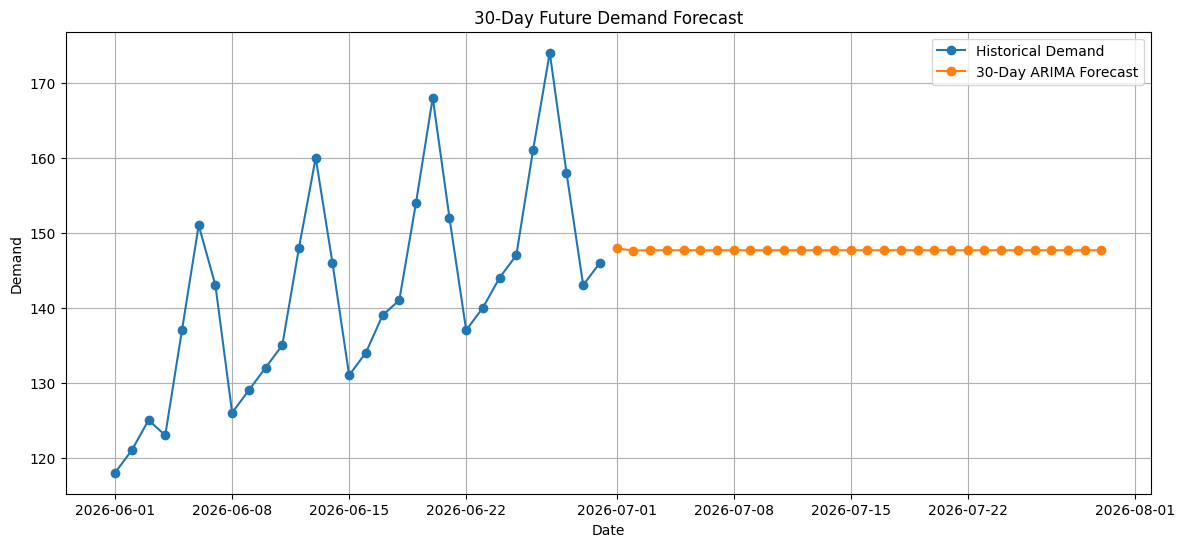

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    demand.index,
        demand,
            label='Historical Demand',
                marker='o'
                )

plt.plot(
                    future_forecast.index,
                        future_forecast,
                            label='30-Day ARIMA Forecast',
                                marker='o'
                                )

plt.title('30-Day Future Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()

In [48]:
forecast_table = pd.DataFrame({
      'Date': future_forecast.index,
          'Forecasted_Demand': future_forecast.values
          })

forecast_table


,Date,Forecasted_Demand
0,2026-07-01,147.906837
1,2026-07-02,147.624183
2,2026-07-03,147.666081
3,2026-07-04,147.659871
4,2026-07-05,147.660791
5,2026-07-06,147.660655
6,2026-07-07,147.660675
7,2026-07-08,147.660672
8,2026-07-09,147.660672
9,2026-07-10,147.660672


In [ ]:
## Conclusion

In this project, daily demand data was analyzed using time-series forecasting techniques.

The time series was decomposed into trend, seasonal, and residual components to understand its underlying patterns. The Augmented Dickey-Fuller (ADF) test was performed to evaluate stationarity, and differencing was applied when required.

An ARIMA model was trained using a training/test split. The model was evaluated using Mean Absolute Percentage Error (MAPE) and Root Mean Squared Error (RMSE).

Finally, the trained ARIMA model was used to generate a 30-day future demand forecast. The forecast provides an estimate of future demand based on historical patterns in the dataset.